In [3]:
# ====================================================
# Import Required Libraries
# ====================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch




In [4]:
# ====================================================
# Dataset Path
# ====================================================
DATASET_PATH = Path("IMS")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH.resolve()}"
    )

print("Dataset found at:")
print(DATASET_PATH.resolve())

Dataset found at:
C:\Users\Abdelrahman Mahmoud\OneDrive\Desktop\predective maintanance\IMS


In [5]:
def get_recording_files(test_folder):
    """
    Find all files inside an IMS test folder.

    Directories are ignored.
    """
    
    files = [
        path for path in test_folder.rglob("*")
        if path.is_file()
    ]
    
    return sorted(files)


for test_name in ["1st_test", "2nd_test", "3rd_test"]:
    
    test_path = DATASET_PATH / test_name
    
    files = get_recording_files(test_path)
    
    print(f"{test_name}: {len(files)} recordings")

1st_test: 2156 recordings
2nd_test: 984 recordings
3rd_test: 6324 recordings


In [6]:
# ====================================================
# Load one recording
# ==================================================== 


test1_files = get_recording_files(DATASET_PATH / "1st_test")

sample_file = test1_files[0]

sample = pd.read_csv(
    sample_file,
    sep=r"\s+",
    header=None,
    engine="python"
)

print("File:", sample_file.name)
print("Shape:", sample.shape)

display(sample.head())

File: 2003.10.22.12.06.24
Shape: (20480, 8)


,0,1,2,3,4,5,6,7
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


In [7]:
# ====================================================
# Check the recording structure
# ====================================================
print("Rows    :", sample.shape[0])
print("Columns :", sample.shape[1])

print("\nData types:")
print(sample.dtypes)

Rows    : 20480
Columns : 8

Data types:
0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object


In [8]:
# ====================================================
# Define the IMS channel mappings
# ====================================================
CHANNEL_MAP = {
    "1st_test": {
        "bearing_1": 0,
        "bearing_2": 2,
        "bearing_3": 4,
        "bearing_4": 6
    },
    
    "2nd_test": {
        "bearing_1": 0,
        "bearing_2": 1,
        "bearing_3": 2,
        "bearing_4": 3
    },
    
    "3rd_test": {
        "bearing_1": 0,
        "bearing_2": 1,
        "bearing_3": 2,
        "bearing_4": 3
    }
}

In [9]:
# ====================================================
# Define which bearings actually fail
# ====================================================

FAILED_BEARINGS = {
    "1st_test": ["bearing_3", "bearing_4"],
    "2nd_test": ["bearing_1"],
    "3rd_test": ["bearing_3"]
}

for test_name, bearings in FAILED_BEARINGS.items():
    print(test_name, "→", bearings)

1st_test → ['bearing_3', 'bearing_4']
2nd_test → ['bearing_1']
3rd_test → ['bearing_3']


In [10]:
# ====================================================
# Convert filename into timestamp
# ====================================================

def parse_timestamp(file_path):
    return pd.to_datetime(
        file_path.name,
        format="%Y.%m.%d.%H.%M.%S",
        errors="coerce"
    )


print(parse_timestamp(sample_file))

2003-10-22 12:06:24


In [11]:
def create_windows(signal, window_size=1024):
    """
    Split a signal into non-overlapping windows.

    Parameters
    ----------
    signal : array-like
        Raw vibration signal.

    window_size : int
        Number of samples in each window.

    Returns
    -------
    windows : ndarray
        Shape = (number_of_windows, window_size)
    """
    
    signal = np.asarray(signal)
    
    n_windows = len(signal) // window_size
    
    trimmed_length = n_windows * window_size
    
    trimmed_signal = signal[:trimmed_length]
    
    windows = trimmed_signal.reshape(
        n_windows,
        window_size
    )
    
    return windows

In [12]:
signal = sample.iloc[:, CHANNEL_MAP["1st_test"]["bearing_3"]].values

windows = create_windows(
    signal,
    window_size=1024
)

print("Original samples :", len(signal))
print("Window shape     :", windows.shape)
print("Number of windows:", len(windows))

Original samples : 20480
Window shape     : (20, 1024)
Number of windows: 20


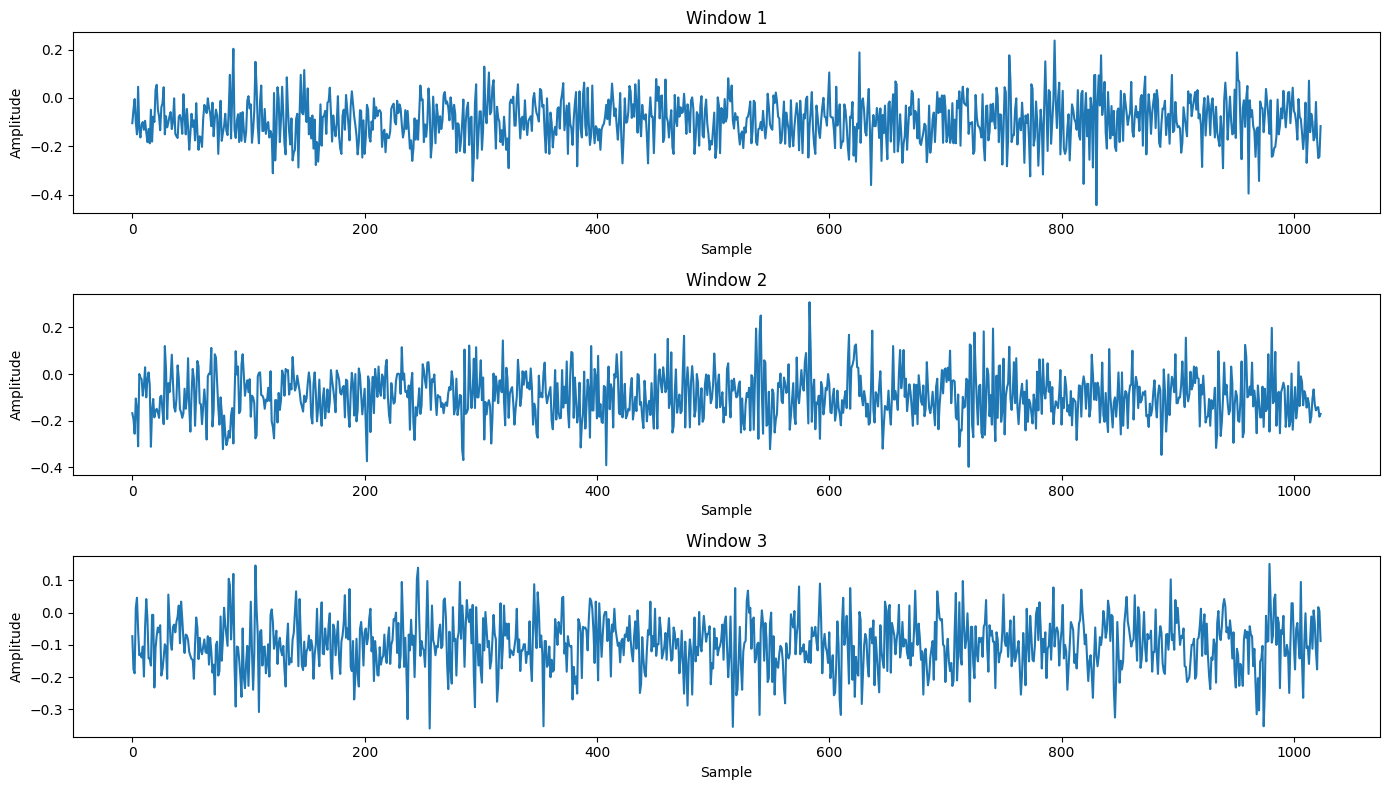

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for i, ax in enumerate(axes):
    ax.plot(windows[i])
    ax.set_title(f"Window {i + 1}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [14]:
def extract_time_features(x):
    """
    Extract time-domain features from one vibration window.
    """
    
    x = np.asarray(x)
    
    abs_x = np.abs(x)
    
    rms = np.sqrt(np.mean(x ** 2))
    
    peak = np.max(abs_x)
    
    mean_abs = np.mean(abs_x)
    
    features = {
        "mean": np.mean(x),
        "std": np.std(x),
        "variance": np.var(x),
        "rms": rms,
        "peak": peak,
        "peak_to_peak": np.ptp(x),
        "skewness": skew(x),
        "kurtosis": kurtosis(x),
        "crest_factor": peak / rms if rms != 0 else 0,
        "shape_factor": rms / mean_abs if mean_abs != 0 else 0,
        "impulse_factor": peak / mean_abs if mean_abs != 0 else 0,
        "energy": np.sum(x ** 2),
        "mean_absolute": mean_abs
    }
    
    return features

In [15]:
def extract_frequency_features(x, fs=20480):
    """
    Extract frequency-domain features using Welch PSD.

    fs = sampling frequency in Hz.
    """
    
    frequencies, psd = welch(
        x,
        fs=fs,
        nperseg=min(256, len(x))
    )
    
    psd_sum = np.sum(psd)
    
    if psd_sum == 0:
        psd_sum = 1e-12
    
    dominant_frequency = frequencies[np.argmax(psd)]
    
    spectral_centroid = (
        np.sum(frequencies * psd) / psd_sum
    )
    
    spectral_bandwidth = np.sqrt(
        np.sum(
            ((frequencies - spectral_centroid) ** 2) * psd
        ) / psd_sum
    )
    
    normalized_psd = psd / psd_sum
    
    spectral_entropy = -np.sum(
        normalized_psd *
        np.log2(normalized_psd + 1e-12)
    )
    
    spectral_energy = np.sum(psd)
    
    return {
        "dominant_frequency": dominant_frequency,
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "spectral_entropy": spectral_entropy,
        "spectral_energy": spectral_energy,
        "max_psd": np.max(psd)
    }

In [16]:
def extract_features(window, fs=20480):
    """
    Extract all time and frequency-domain features.
    """
    
    time_features = extract_time_features(window)
    
    frequency_features = extract_frequency_features(
        window,
        fs=fs
    )
    
    return {
        **time_features,
        **frequency_features
    }

In [17]:
WINDOW_SIZE = 1024
SAMPLING_FREQUENCY = 20480

all_rows = []

for test_name, failed_bearings in FAILED_BEARINGS.items():
    
    test_path = DATASET_PATH / test_name
    
    recording_files = get_recording_files(test_path)
    
    recording_files = sorted(
        recording_files,
        key=parse_timestamp
    )
    
    print(f"\nProcessing {test_name}...")
    print(f"Total recordings: {len(recording_files)}")
    
    for recording_index, file_path in enumerate(recording_files):
        
        timestamp = parse_timestamp(file_path)
        
        data = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            engine="python"
        )
        
        for bearing_name in failed_bearings:
            
            channel_index = CHANNEL_MAP[test_name][bearing_name]
            
            signal = data.iloc[:, channel_index].values
            
            windows = create_windows(
                signal,
                window_size=WINDOW_SIZE
            )
            
            for window_index, window in enumerate(windows):
                
                feature_row = extract_features(
                    window,
                    fs=SAMPLING_FREQUENCY
                )
                
                feature_row["test_set"] = test_name
                feature_row["bearing"] = bearing_name
                feature_row["recording_index"] = recording_index
                feature_row["window_index"] = window_index
                feature_row["timestamp"] = timestamp
                
                all_rows.append(feature_row)
    
    print(f"Finished {test_name}")

features_df = pd.DataFrame(all_rows)

print("\nFinal shape:", features_df.shape)


Processing 1st_test...
Total recordings: 2156
Finished 1st_test

Processing 2nd_test...
Total recordings: 984
Finished 2nd_test

Processing 3rd_test...
Total recordings: 6324
Finished 3rd_test

Final shape: (232400, 24)


In [18]:
features = extract_features(windows[0])

pd.DataFrame([features])

,mean,std,variance,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,impulse_factor,energy,mean_absolute,dominant_frequency,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_energy,max_psd
0,0.003452,0.001522,0.000002,0.003773,0.007,0.005,0.131693,-1.860826,1.855426,1.092861,2.027723,0.014575,0.003452,160.0,3499.675103,3541.730233,5.717749,2.633541e-08,3.633082e-09


In [19]:
features_df = features_df.sort_values(
    by=[
        "test_set",
        "bearing",
        "timestamp",
        "window_index"
    ]
).reset_index(drop=True)

features_df.head()

,mean,std,variance,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,...,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_energy,max_psd,test_set,bearing,recording_index,window_index,timestamp
0,-0.092337,0.089429,0.007997,0.128544,0.444,0.681,-0.034094,0.300560,3.454068,1.221242,...,4692.528749,2578.613850,6.336685,0.000102,0.000006,1st_test,bearing_3,0,0,2003-10-22 12:06:24
1,-0.093666,0.099392,0.009879,0.136573,0.398,0.706,0.200843,0.248454,2.914201,1.208043,...,4623.970771,2775.059659,6.370781,0.000122,0.000007,1st_test,bearing_3,0,1,2003-10-22 12:06:24
2,-0.096662,0.080187,0.006430,0.125593,0.359,0.510,-0.101341,0.290571,2.858441,1.189838,...,4132.866720,2660.288748,6.412999,0.000080,0.000005,1st_test,bearing_3,0,2,2003-10-22 12:06:24
3,-0.096557,0.091579,0.008387,0.133078,0.432,0.647,-0.047599,0.126897,3.246208,1.217891,...,4073.166371,2610.632796,6.351947,0.000099,0.000009,1st_test,bearing_3,0,3,2003-10-22 12:06:24
4,-0.087128,0.099850,0.009970,0.132519,0.452,0.782,0.151351,0.683224,3.410828,1.220836,...,4893.917207,2736.680907,6.292802,0.000130,0.000007,1st_test,bearing_3,0,4,2003-10-22 12:06:24


In [20]:
features_df["failure_timestamp"] = (
    features_df
    .groupby(["test_set", "bearing"])["timestamp"]
    .transform("max")
)

features_df["RUL_minutes"] = (
    features_df["failure_timestamp"] - features_df["timestamp"]
).dt.total_seconds() / 60

features_df["RUL_hours"] = (
    features_df["RUL_minutes"] / 60
)

features_df[
    [
        "test_set",
        "bearing",
        "timestamp",
        "RUL_hours"
    ]
].head()

,test_set,bearing,timestamp,RUL_hours
0,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
1,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
2,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
3,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
4,1st_test,bearing_3,2003-10-22 12:06:24,827.558889


In [21]:
features_df["RUL_fraction"] = (
    features_df["RUL_hours"] /
    features_df.groupby(["test_set", "bearing"])["RUL_hours"]
    .transform("max")
)

features_df["RUL_fraction"] = features_df["RUL_fraction"].clip(0, 1)  

In [22]:
features_df["health_index"] = (
    features_df["RUL_fraction"] * 100
)

features_df[
    [
        "timestamp",
        "RUL_hours",
        "health_index"
    ]
].head()

,timestamp,RUL_hours,health_index
0,2003-10-22 12:06:24,827.558889,100.0
1,2003-10-22 12:06:24,827.558889,100.0
2,2003-10-22 12:06:24,827.558889,100.0
3,2003-10-22 12:06:24,827.558889,100.0
4,2003-10-22 12:06:24,827.558889,100.0


In [23]:
features_df["failure_risk_score"] = (
    100 - features_df["health_index"]
)

features_df["failure_risk_score"] = (
    features_df["failure_risk_score"].clip(0, 100)
)


In [24]:
OUTPUT_PATH = Path("ims_features_dataset.csv")

features_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Dataset saved to:")
print(OUTPUT_PATH.resolve())

Dataset saved to:
C:\Users\Abdelrahman Mahmoud\OneDrive\Desktop\predective maintanance\ims_features_dataset.csv


In [25]:
df=pd.read_csv("ims_features_dataset.csv")
df.shape
df.duplicated().sum()

np.int64(0)

In [26]:
# ====================================================
# Visualization Setup
# ====================================================
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

FAILING_BEARING_GROUPS = list(
    features_df[["test_set", "bearing"]]
    .drop_duplicates()
    .sort_values(["test_set", "bearing"])
    .itertuples(index=False)
)

print("Bearing groups in dataset:")
for group in FAILING_BEARING_GROUPS:
    print(" -", group.test_set, "/", group.bearing)

Bearing groups in dataset:
 - 1st_test / bearing_3
 - 1st_test / bearing_4
 - 2nd_test / bearing_1
 - 3rd_test / bearing_3


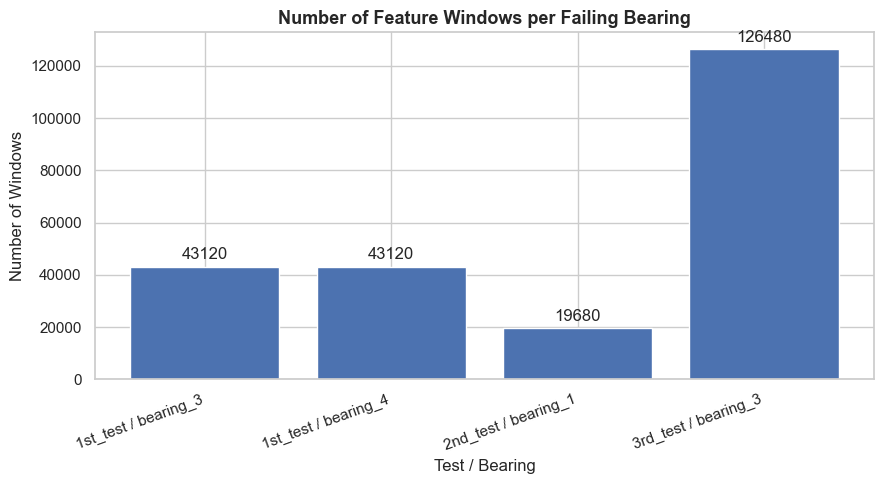

In [27]:
# ====================================================
# Windows per Bearing/Test
# ====================================================
window_counts = (
    features_df
    .groupby(["test_set", "bearing"])
    .size()
    .reset_index(name="n_windows")
)
window_counts["label"] = window_counts["test_set"] + " / " + window_counts["bearing"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(window_counts["label"], window_counts["n_windows"], color="#4C72B0")
ax.bar_label(bars, padding=3)
ax.set_title("Number of Feature Windows per Failing Bearing")
ax.set_xlabel("Test / Bearing")
ax.set_ylabel("Number of Windows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_windows_per_bearing.png")
plt.show()

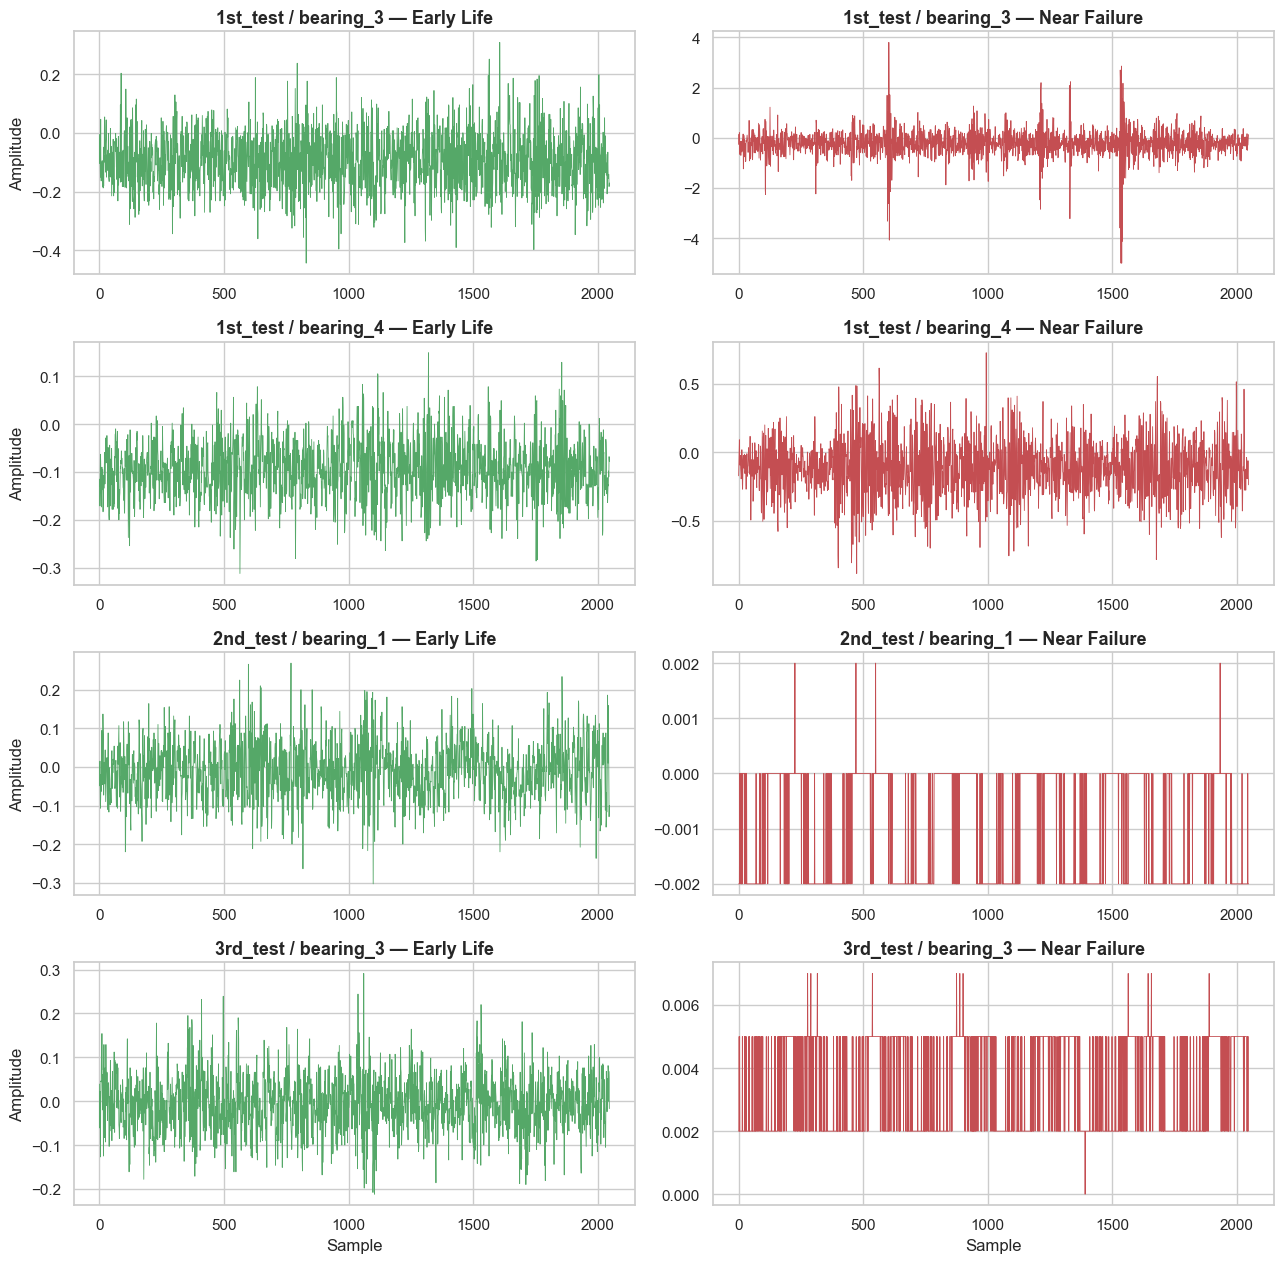

In [28]:
# ====================================================
# Raw Waveform Comparison: Early Life vs Near Failure
# ====================================================

def load_waveform(test_name, bearing_name, file_path):
    data = pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")
    channel_index = CHANNEL_MAP[test_name][bearing_name]
    return data.iloc[:, channel_index].values


n_groups = len(FAILING_BEARING_GROUPS)
fig, axes = plt.subplots(n_groups, 2, figsize=(13, 3.2 * n_groups))
if n_groups == 1:
    axes = axes.reshape(1, -1)

for row, group in enumerate(FAILING_BEARING_GROUPS):
    test_name, bearing_name = group.test_set, group.bearing

    test_path = DATASET_PATH / test_name
    recording_files = sorted(get_recording_files(test_path), key=parse_timestamp)

    early_signal = load_waveform(test_name, bearing_name, recording_files[0])
    late_signal = load_waveform(test_name, bearing_name, recording_files[-1])

    axes[row, 0].plot(early_signal[:2048], linewidth=0.6, color="#55A868")
    axes[row, 0].set_title(f"{test_name} / {bearing_name} — Early Life")
    axes[row, 0].set_ylabel("Amplitude")

    axes[row, 1].plot(late_signal[:2048], linewidth=0.6, color="#C44E52")
    axes[row, 1].set_title(f"{test_name} / {bearing_name} — Near Failure")

for ax in axes[-1]:
    ax.set_xlabel("Sample")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_waveform_early_vs_late.png")
plt.show()

### Type 1 — Wears out slowly (1st_test bearings)
Think of it like a tire wearing down evenly. The whole surface gets rougher over time. So the signal just gets noisier and noisier everywhere, all the time.

Type 2 — Has one damaged spot (2nd_test / 3rd_test bearings)
Think of it like a tiny crack in one spot on a spinning wheel. Most of the time it's smooth. But every time that one damaged spot rotates past, it gives a little "thump." So the signal is quiet... quiet... quiet... spike... quiet... quiet... spike.

That's why they look different. Different damage = different shape.

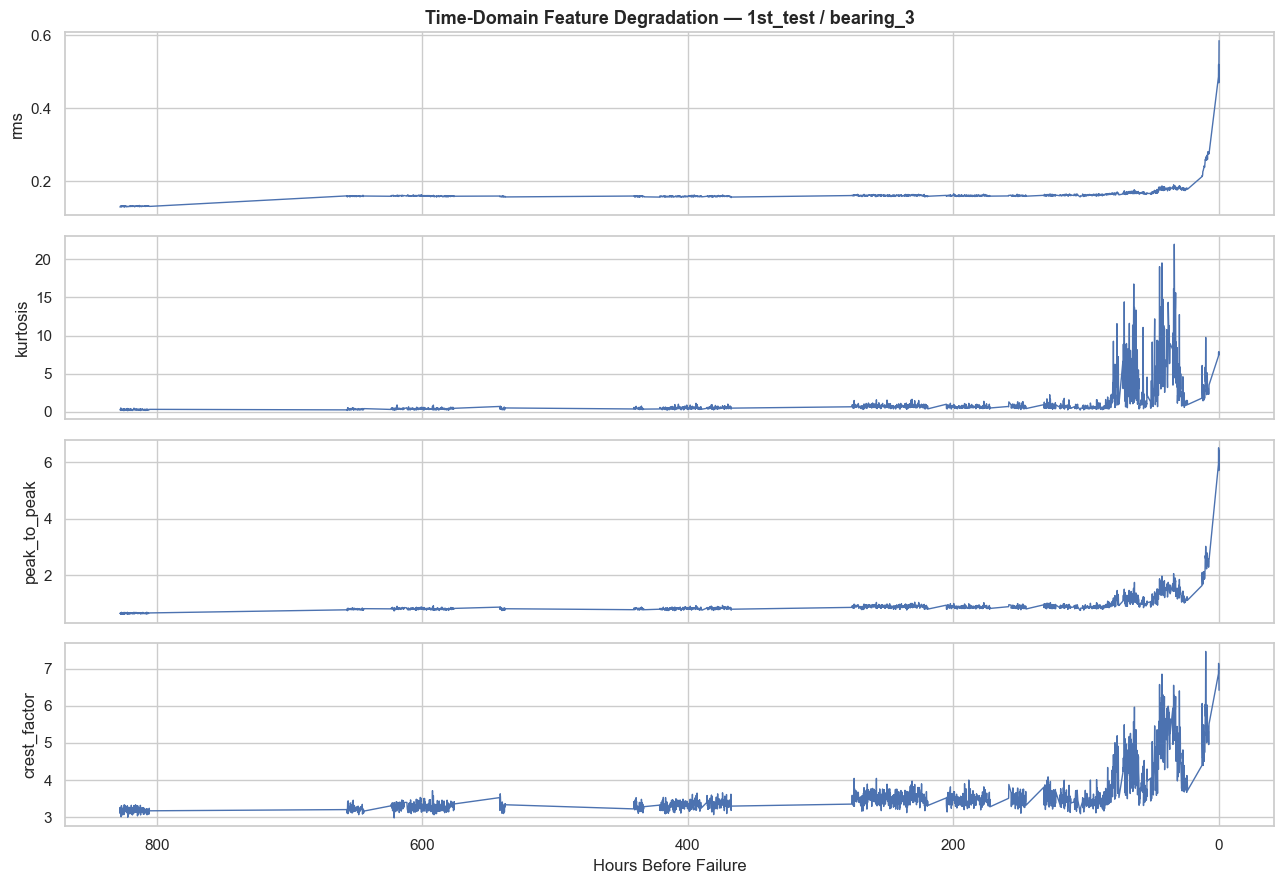

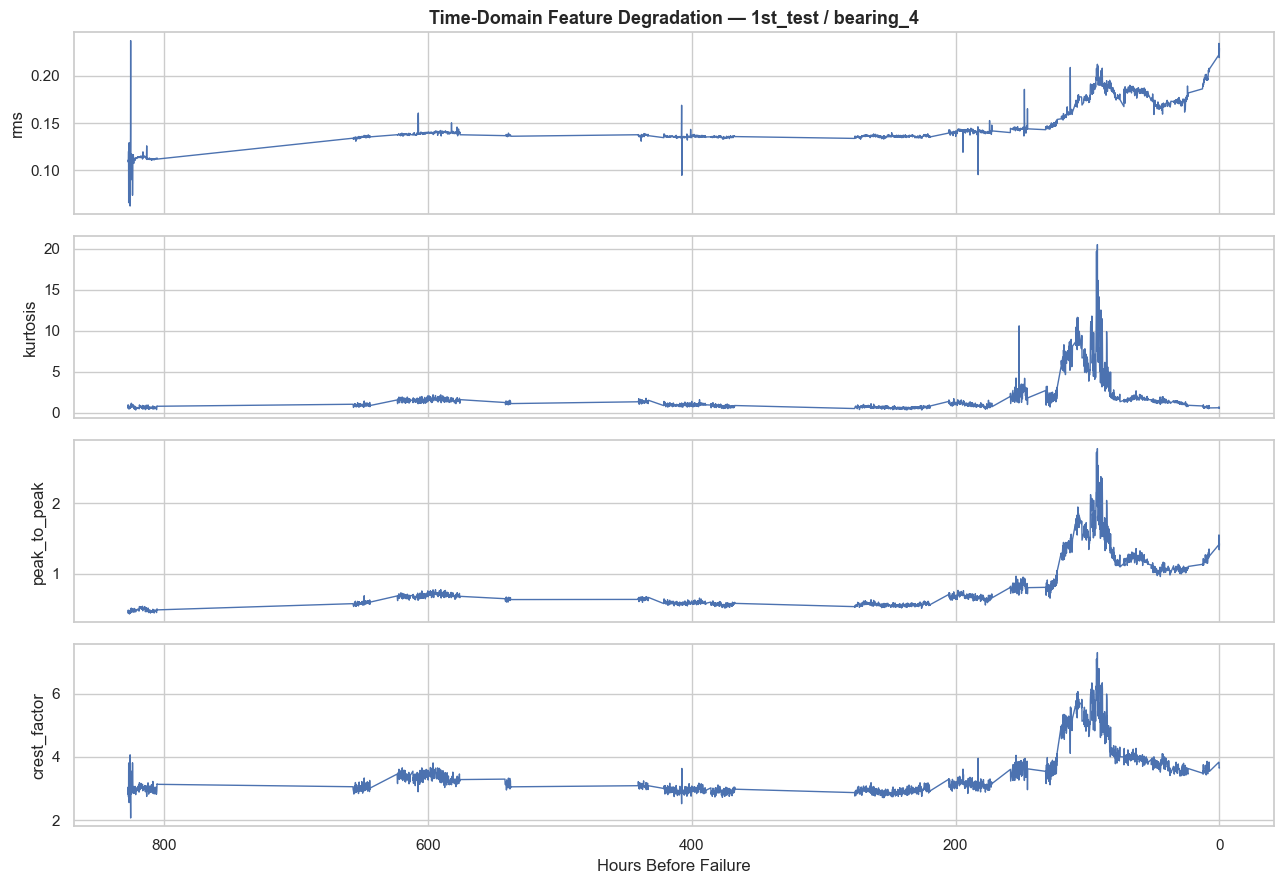

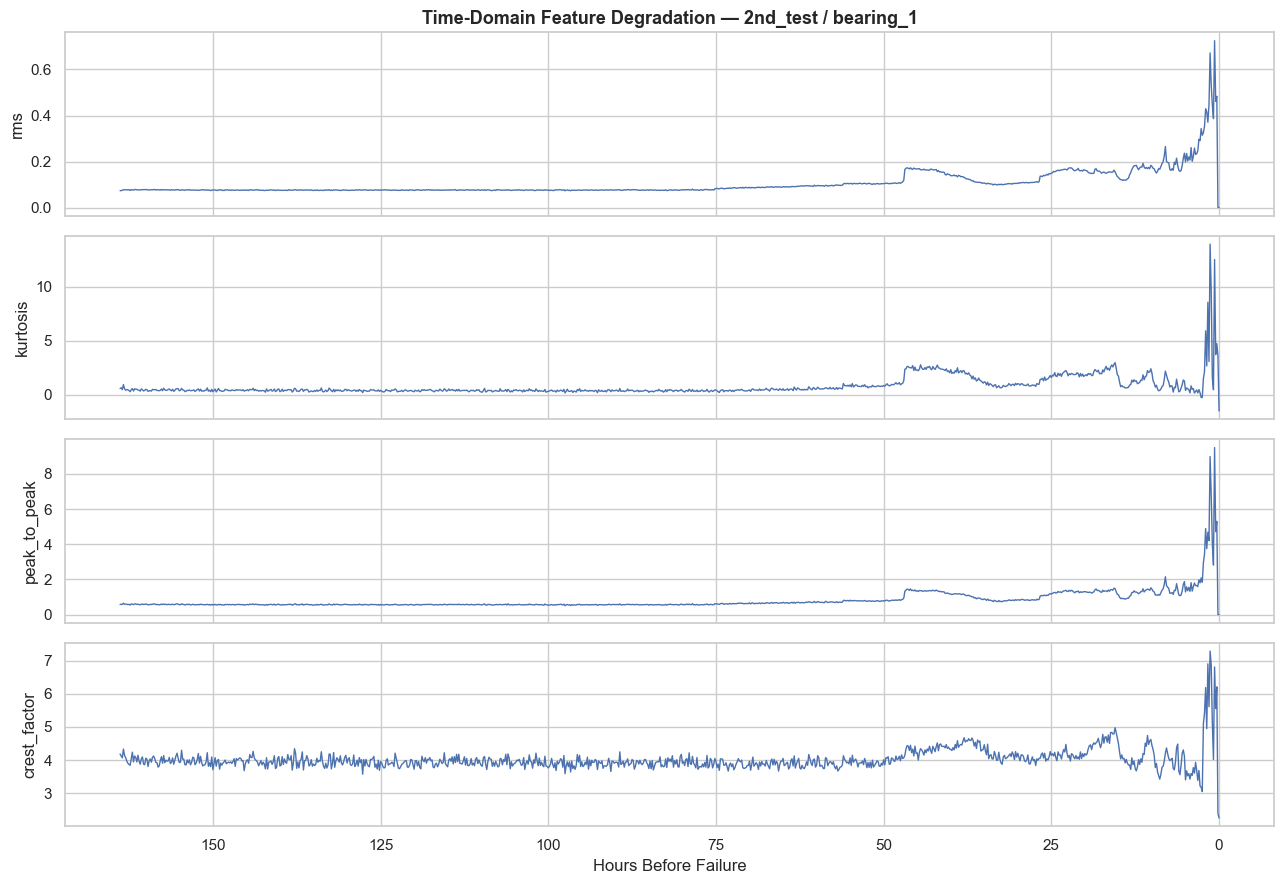

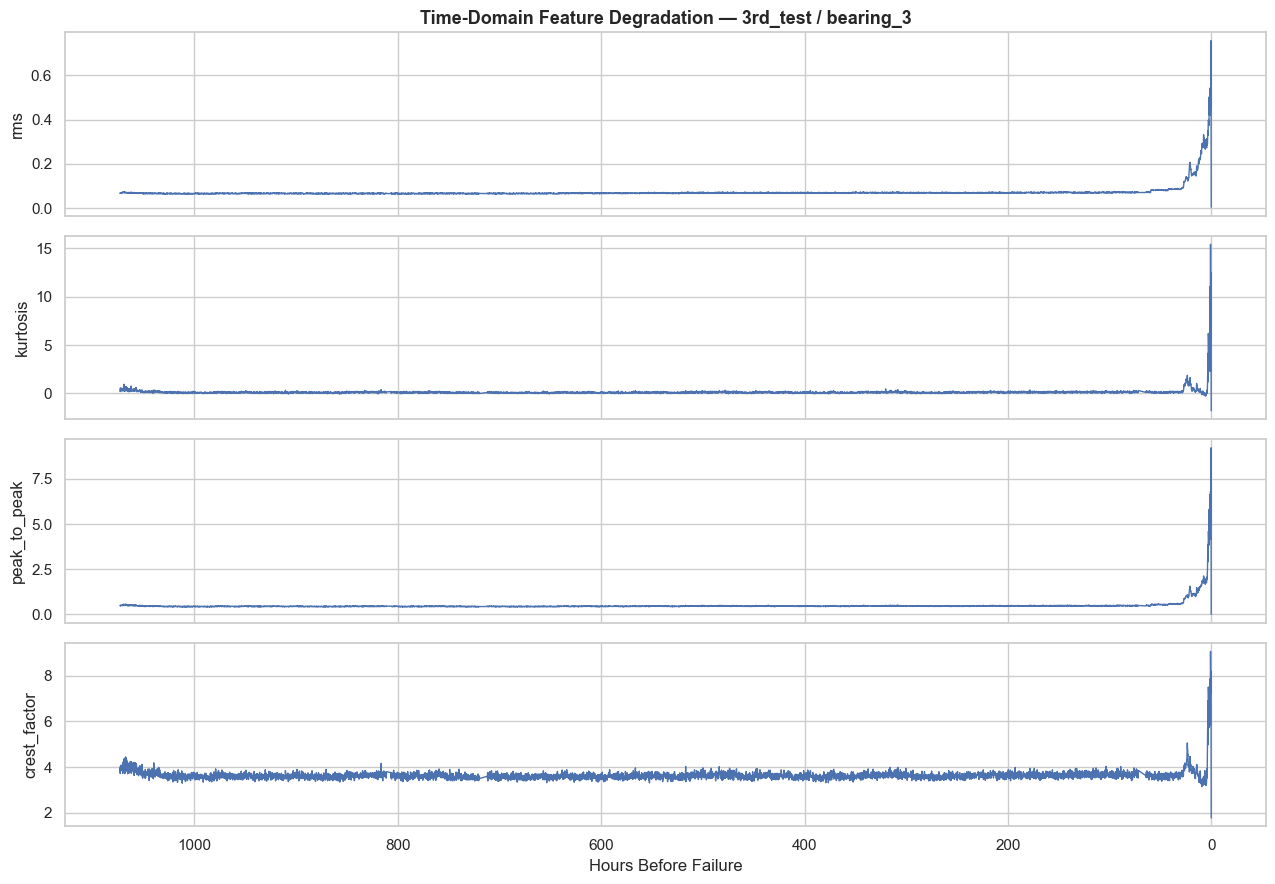

In [29]:
# ====================================================
# Time-Domain Degradation Trends (per bearing, vs hours-to-failure)
# ====================================================
TIME_FEATURES_TO_PLOT = ["rms", "kurtosis", "peak_to_peak", "crest_factor"]

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[TIME_FEATURES_TO_PLOT]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )

    fig, axes = plt.subplots(len(TIME_FEATURES_TO_PLOT), 1, figsize=(13, 9), sharex=True)

    for ax, feature in zip(axes, TIME_FEATURES_TO_PLOT):
        ax.plot(trend["RUL_hours"], trend[feature], color="#4C72B0", linewidth=1)
        ax.set_ylabel(feature)

    # Shared x-axis: invert ONCE, after the loop. Calling invert_xaxis() once
    # per subplot above toggles the shared axis back and forth, and cancels
    # out entirely on an even number of features. Left = early life, right = failure.
    axes[0].invert_xaxis()

    axes[0].set_title(f"Time-Domain Feature Degradation — {test_name} / {bearing_name}")
    axes[-1].set_xlabel("Hours Before Failure")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_time_features_{test_name}_{bearing_name}.png")
    plt.show()

### The one non-obvious thing to mention (this impresses in a presentation):
### Kurtosis sometimes drops back down even as the bearing gets worse (you can see this in bearing_3 — busy for a while, then flat again before the end). That's not the bearing healing. It's that once the defect is big enough, impacts overlap and blend into continuous noise — statistically it starts looking "smooth" again even though it's more damaged. RMS keeps rising because energy never stops increasing; kurtosis just changes character.

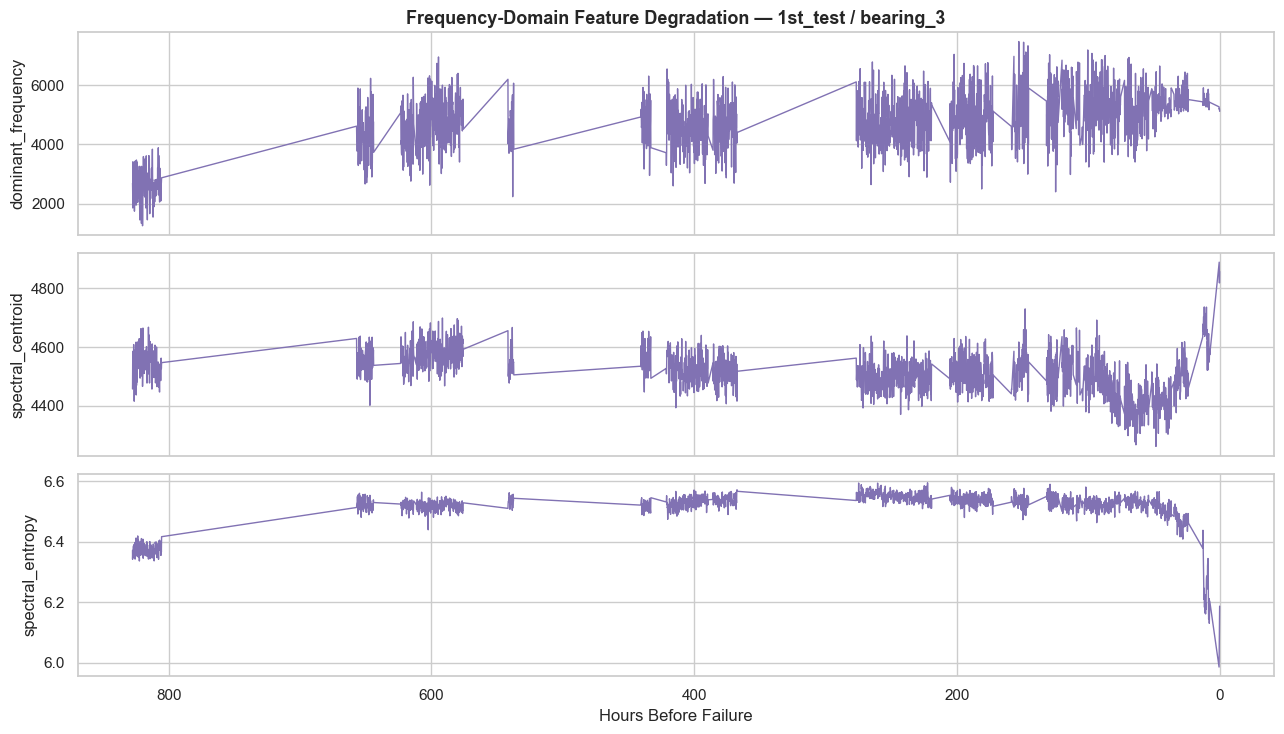

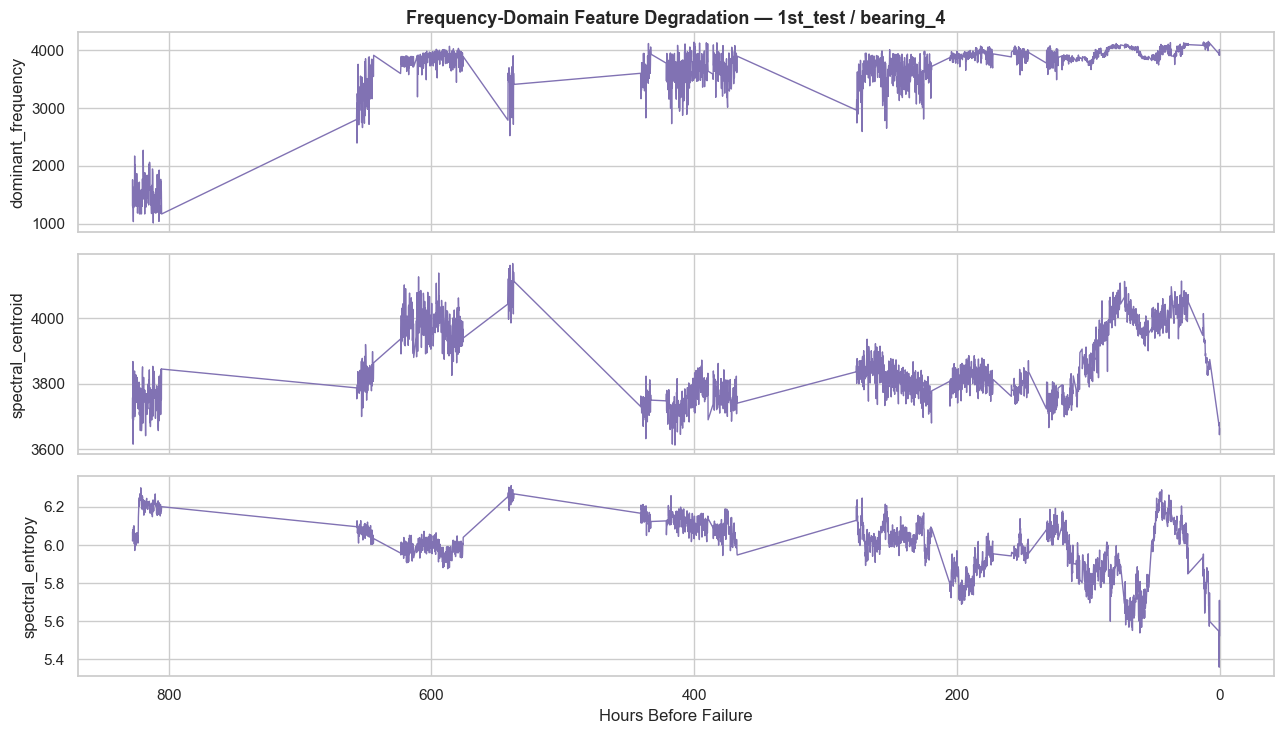

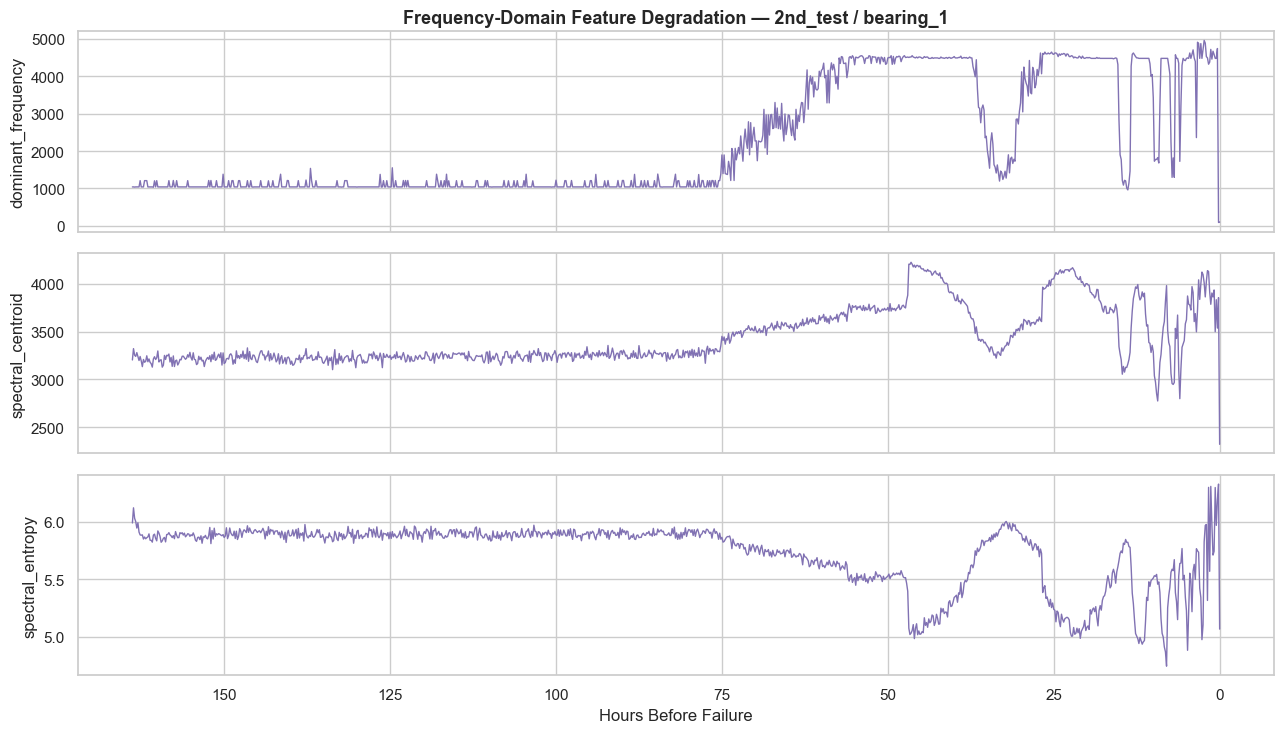

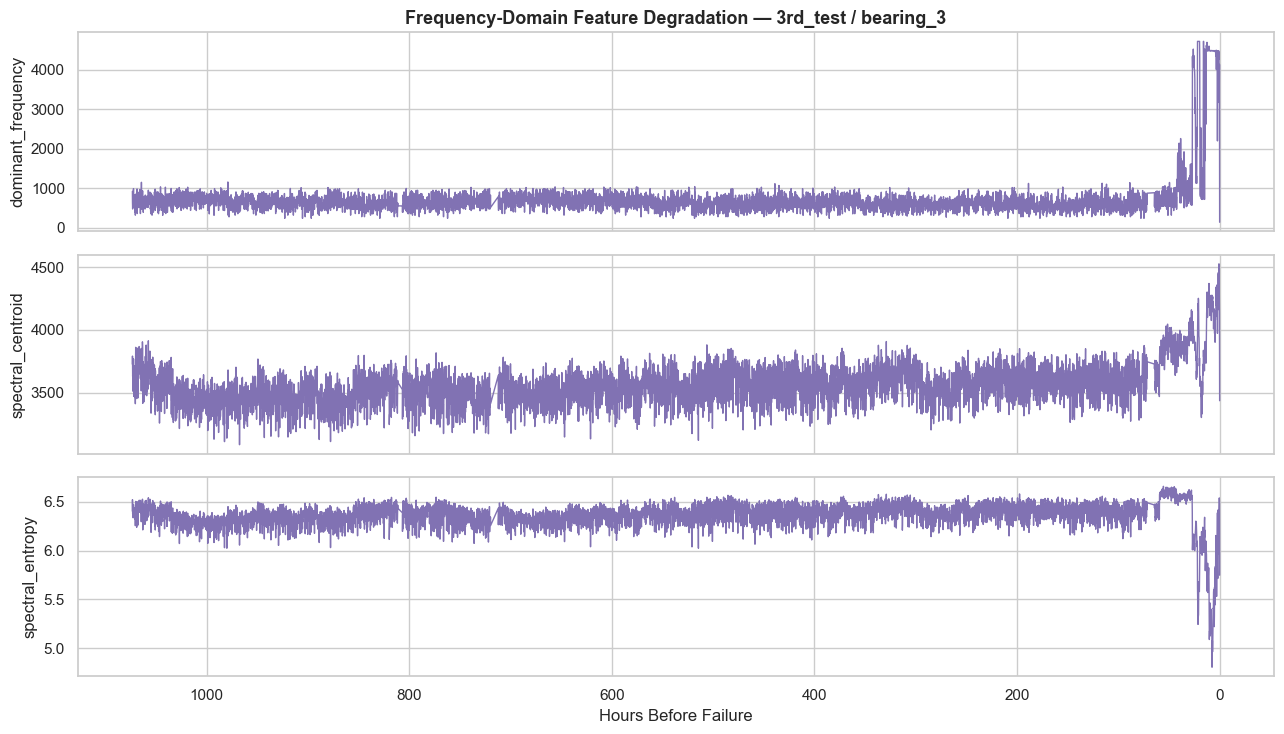

In [30]:
# ====================================================
# Frequency-Domain Degradation Trends (per bearing, vs hours-to-failure)
# ====================================================
FREQ_FEATURES_TO_PLOT = ["dominant_frequency", "spectral_centroid", "spectral_entropy"]

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[FREQ_FEATURES_TO_PLOT]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )

    fig, axes = plt.subplots(len(FREQ_FEATURES_TO_PLOT), 1, figsize=(13, 7.5), sharex=True)

    for ax, feature in zip(axes, FREQ_FEATURES_TO_PLOT):
        ax.plot(trend["RUL_hours"], trend[feature], color="#8172B3", linewidth=1)
        ax.set_ylabel(feature)
        ax.invert_xaxis()

    axes[0].set_title(f"Frequency-Domain Feature Degradation — {test_name} / {bearing_name}")
    axes[-1].set_xlabel("Hours Before Failure")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"04_freq_features_{test_name}_{bearing_name}.png")
    plt.show()

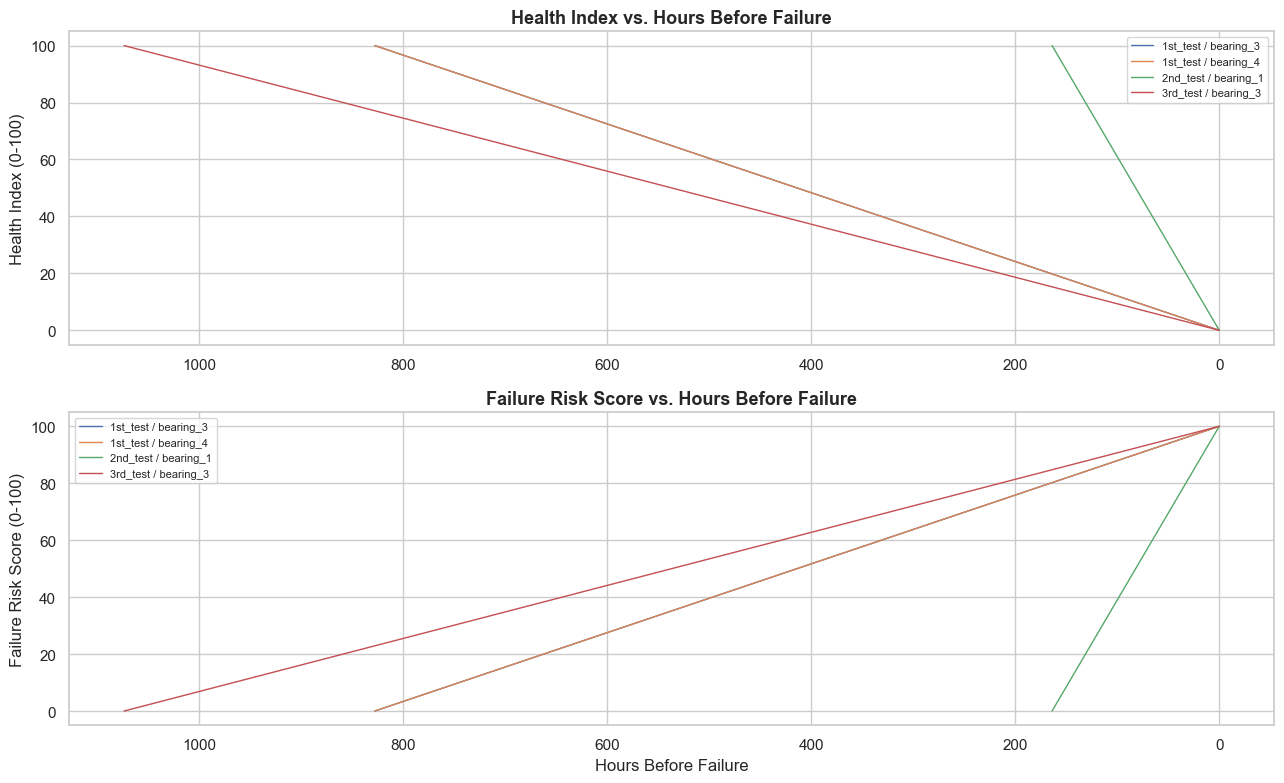

In [31]:
# ====================================================
# Health Index / Failure Risk Score vs Hours-to-Failure (all bearings)
# ====================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[["health_index", "failure_risk_score"]]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )
    label = f"{test_name} / {bearing_name}"

    axes[0].plot(trend["RUL_hours"], trend["health_index"], label=label, linewidth=1)
    axes[1].plot(trend["RUL_hours"], trend["failure_risk_score"], label=label, linewidth=1)

axes[0].set_title("Health Index vs. Hours Before Failure")
axes[0].set_ylabel("Health Index (0-100)")
axes[0].invert_xaxis()
axes[0].legend(fontsize=8)

axes[1].set_title("Failure Risk Score vs. Hours Before Failure")
axes[1].set_ylabel("Failure Risk Score (0-100)")
axes[1].set_xlabel("Hours Before Failure")
axes[1].invert_xaxis()
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_health_index_failure_risk.png")
plt.show()

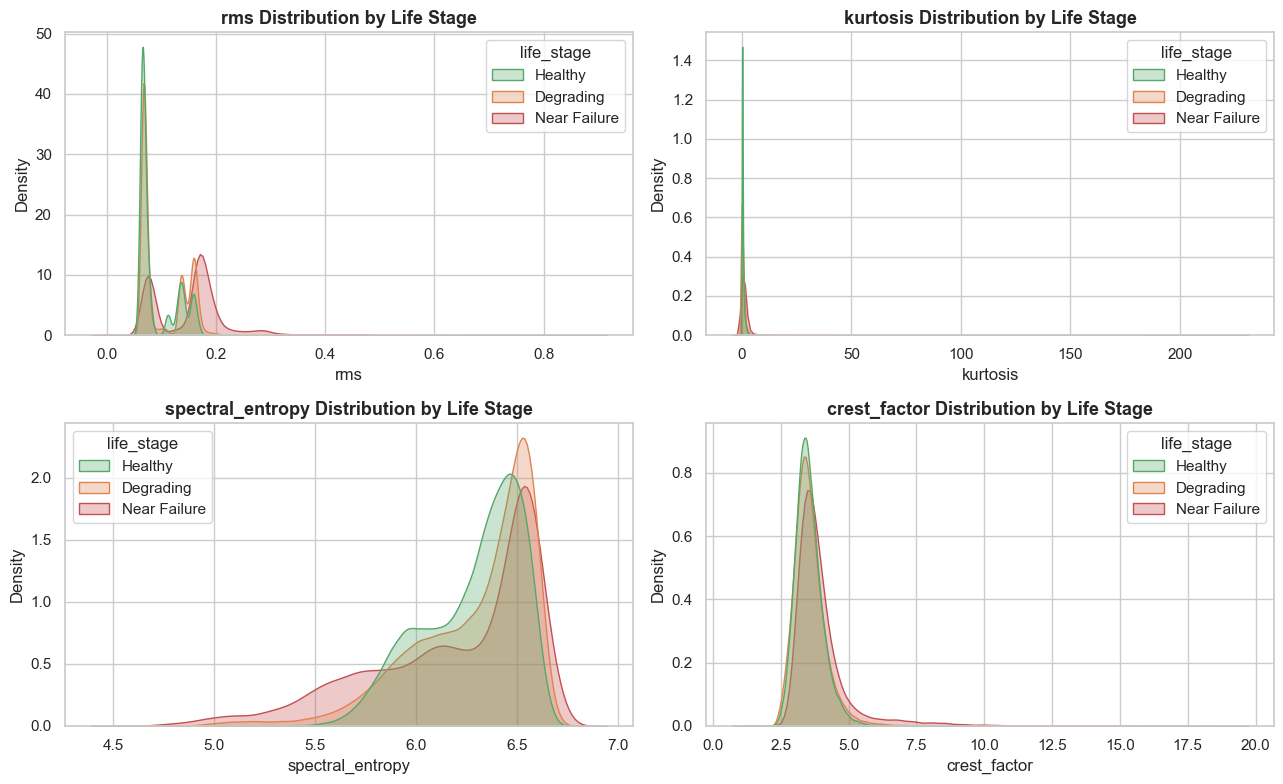

In [32]:
# ====================================================
# Distribution Shift Across Life Stages
# ====================================================
DIST_FEATURES = ["rms", "kurtosis", "spectral_entropy", "crest_factor"]

features_df["life_stage"] = np.select(
    [features_df["RUL_fraction"] > 0.7, features_df["RUL_fraction"] < 0.1],
    ["Healthy", "Near Failure"],
    default="Degrading"
)

palette = {"Healthy": "#55A868", "Degrading": "#DD8452", "Near Failure": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, feature in zip(axes, DIST_FEATURES):
    sns.kdeplot(
        data=features_df,
        x=feature,
        hue="life_stage",
        hue_order=["Healthy", "Degrading", "Near Failure"],
        palette=palette,
        fill=True,
        alpha=0.3,
        common_norm=False,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution by Life Stage")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_feature_distributions_life_stage.png")
plt.show()

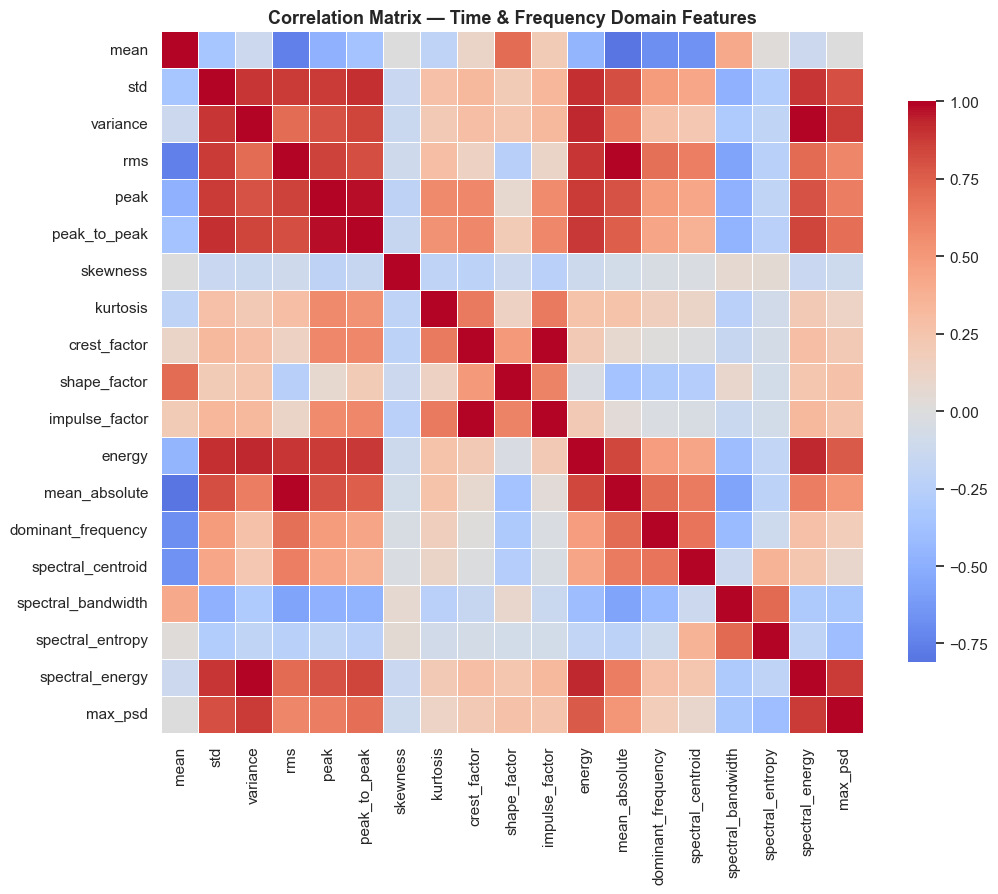

In [33]:
# ====================================================
# Correlation Matrix — Time & Frequency Domain Features
# ====================================================
NUMERIC_FEATURE_COLS = [
    "mean", "std", "variance", "rms", "peak", "peak_to_peak",
    "skewness", "kurtosis", "crest_factor", "shape_factor",
    "impulse_factor", "energy", "mean_absolute",
    "dominant_frequency", "spectral_centroid", "spectral_bandwidth",
    "spectral_entropy", "spectral_energy", "max_psd"
]

corr_matrix = features_df[NUMERIC_FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Correlation Matrix — Time & Frequency Domain Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_feature_correlation_heatmap.png")
plt.show()

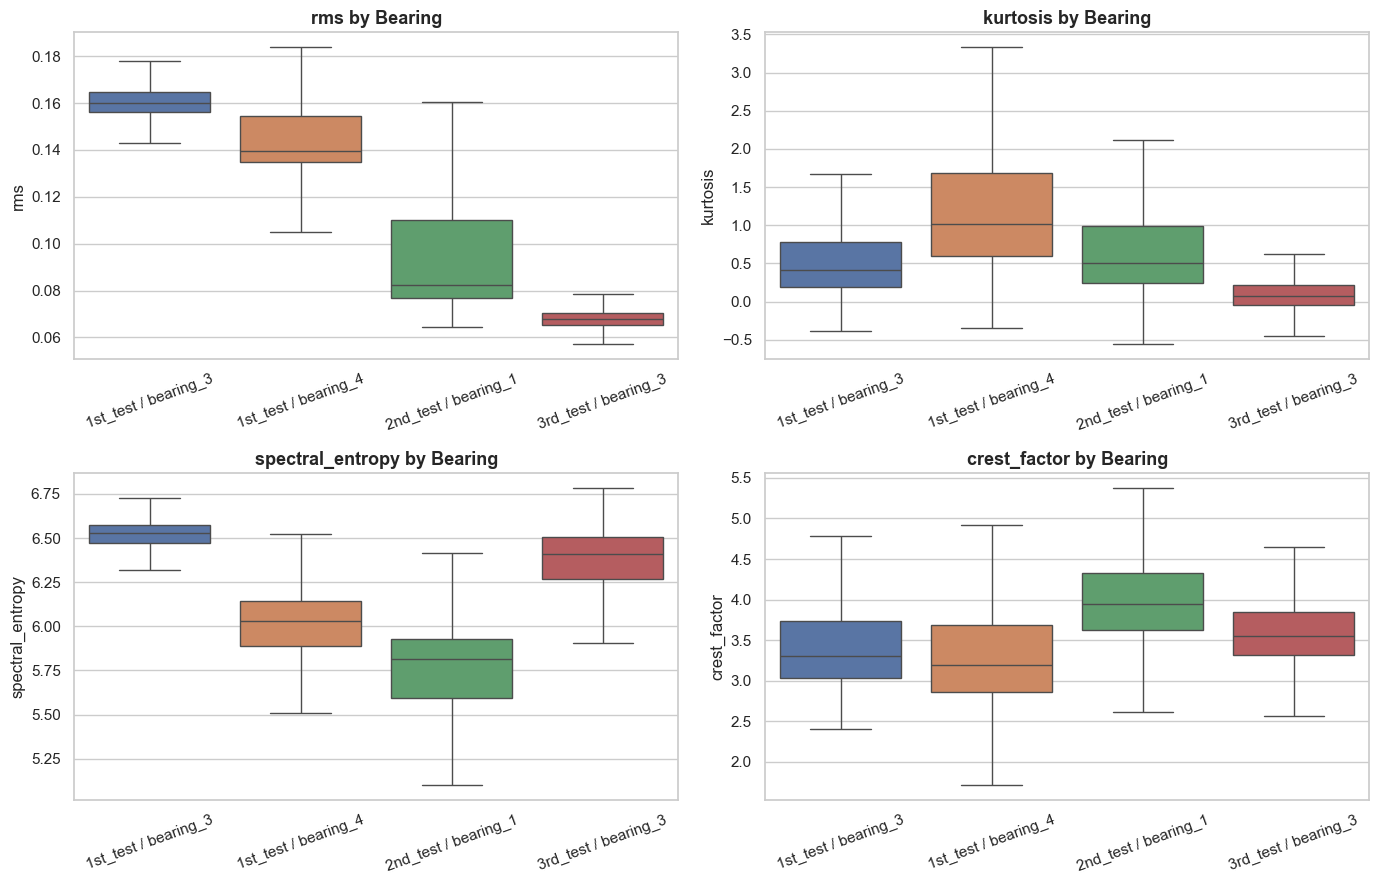

In [34]:
# ====================================================
# Feature Spread by Bearing
# ====================================================
features_df["group"] = features_df["test_set"] + " / " + features_df["bearing"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, feature in zip(axes, DIST_FEATURES):
    sns.boxplot(
        data=features_df,
        x="group",
        y=feature,
        hue="group",
        palette="deep",
        legend=False,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f"{feature} by Bearing")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_feature_boxplots_by_bearing.png")
plt.show()

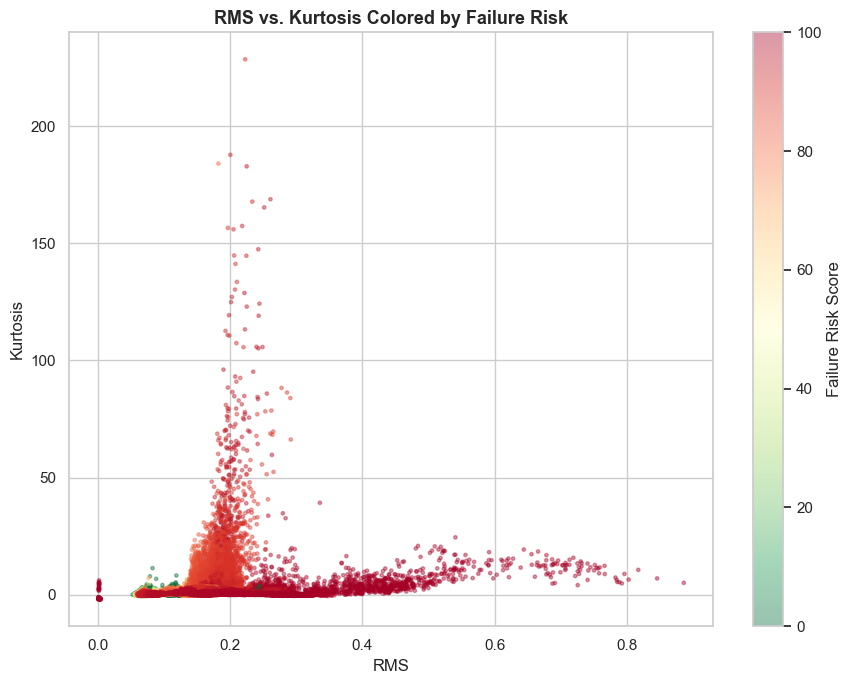

In [35]:
# ====================================================
# RMS vs Kurtosis Scatter — Failure Progression
# ====================================================
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    features_df["rms"],
    features_df["kurtosis"],
    c=features_df["failure_risk_score"],
    cmap="RdYlGn_r",
    s=6,
    alpha=0.4
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Failure Risk Score")
ax.set_xlabel("RMS")
ax.set_ylabel("Kurtosis")
ax.set_title("RMS vs. Kurtosis Colored by Failure Risk")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_rms_vs_kurtosis_risk.png")
plt.show()

In [36]:
# ====================================================
# Summary Statistics Table
# ====================================================
summary_stats = (
    features_df
    .groupby(["test_set", "bearing"])[NUMERIC_FEATURE_COLS]
    .agg(["mean", "std", "min", "max"])
)
summary_stats

mean                                     std  \
                        mean       std       min       max      mean   
test_set bearing                                                       
1st_test bearing_3 -0.112761  0.010216 -0.243764  0.537065  0.115125   
         bearing_4 -0.112849  0.008290 -0.234787  0.017646  0.091390   
2nd_test bearing_1 -0.001943  0.002810 -0.037029  0.027100  0.105967   
3rd_test bearing_3 -0.002073  0.003780 -0.360870  0.411486  0.072243   

                                                  variance            ...  \
                         std       min       max      mean       std  ...   
test_set bearing                                                      ...   
1st_test bearing_3  0.024332  0.079160  0.778452  0.013846  0.012213  ...   
         bearing_4  0.029332  0.048812  0.265877  0.009212  0.006566  ...   
2nd_test bearing_1  0.058358  0.000879  0.765265  0.014634  0.030573  ...   
3rd_test bearing_3  0.030792  0.001490  0.854622  0.006167  0.014339  ...   

                   spectral_entropy           spectral_energy            \
                                min       max            mean       std   
test_set bearing                                                          
1st_test bearing_3         5.189735  6.738315        0.000173  0.000157   
         bearing_4         4.931278  6.594852        0.000115  0.000084   
2nd_test bearing_1         4.552171  6.620348        0.000181  0.000382   
3rd_test bearing_3         4.623731  6.782413        0.000076  0.000173   

                                             max_psd                          \
                             min       max      mean       std           min   
test_set bearing                                                               
1st_test bearing_3  7.640319e-05  0.008378  0.000008  0.000016  2.803596e-06   
         bearing_4  2.719083e-05  0.000950  0.000010  0.000010  1.456928e-06   
2nd_test bearing_1  8.931479e-09  0.007450  0.000020  0.000038  5.245115e-10   
3rd_test bearing_3  2.477484e-08  0.007881  0.000007  0.000021  2.950198e-09   

                              
                         max  
test_set bearing              
1st_test bearing_3  0.001218  
         bearing_4  0.000129  
2nd_test bearing_1  0.000705  
3rd_test bearing_3  0.000639  

[4 rows x 76 columns]

## Step 5 — Remove Highly Correlated Features

Using `corr_matrix` computed above, drop one feature from every pair whose absolute correlation exceeds `CORR_THRESHOLD`. This keeps the feature set non-redundant before modeling.

In [37]:
# ====================================================
# Drop Highly Correlated Features
# ====================================================
CORR_THRESHOLD = 0.90

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = []
for column in upper.columns:
    if column in to_drop:
        continue
    correlated_with = upper.index[upper[column] > CORR_THRESHOLD].tolist()
    for other in correlated_with:
        if other not in to_drop and other != column:
            to_drop.append(other)

to_drop = sorted(set(to_drop))
SELECTED_FEATURE_COLS = [c for c in NUMERIC_FEATURE_COLS if c not in to_drop]

print(f"Dropping {len(to_drop)} highly correlated feature(s) (|r| > {CORR_THRESHOLD}):")
print(to_drop)
print(f"\nKeeping {len(SELECTED_FEATURE_COLS)} feature(s):")
print(SELECTED_FEATURE_COLS)


Dropping 6 highly correlated feature(s) (|r| > 0.9):
['crest_factor', 'energy', 'peak', 'rms', 'std', 'variance']

Keeping 13 feature(s):
['mean', 'peak_to_peak', 'skewness', 'kurtosis', 'shape_factor', 'impulse_factor', 'mean_absolute', 'dominant_frequency', 'spectral_centroid', 'spectral_bandwidth', 'spectral_entropy', 'spectral_energy', 'max_psd']


## Step 6 — Train/Test Split (corrected for run-to-failure data)

**Modification made to the original request:** a random row-level split, or a split that only reweights rows near failure, will leak information. Consecutive windows inside the same run are nearly identical (they come from the same slowly-evolving vibration signal seconds apart), so a random shuffle would put near-duplicate windows from the *same failure event* on both sides of the split — the model would look far more accurate than it really is, and could still end up with an entire run's failure region isolated in one subset purely by chance.

The fix that actually prevents both problems at once: split by **whole run** (`test_set` + `bearing`), not by row. Every run is a complete healthy-to-failure trajectory, so holding a run out keeps its full life history — early life through failure — together in one subset. No row from a held-out run's degradation curve leaks into training, and no split accidentally isolates only the failure portion of a run.

In [38]:
# ====================================================
# Group the data by run (test_set + bearing = one full life history)
# ====================================================
features_df["run_id"] = features_df["test_set"] + "_" + features_df["bearing"]

run_ids = sorted(features_df["run_id"].unique())
print("Available runs (each is one complete run-to-failure trajectory):")
for r in run_ids:
    print(" -", r)


Available runs (each is one complete run-to-failure trajectory):
 - 1st_test_bearing_3
 - 1st_test_bearing_4
 - 2nd_test_bearing_1
 - 3rd_test_bearing_3


In [39]:
# ====================================================
# Hold out one entire run for testing (edit TEST_RUN to choose which)
# ====================================================
TEST_RUN = run_ids[-1]

train_df = features_df[features_df["run_id"] != TEST_RUN].sort_values(
    ["run_id", "timestamp", "window_index"]
).reset_index(drop=True)

test_df = features_df[features_df["run_id"] == TEST_RUN].sort_values(
    ["timestamp", "window_index"]
).reset_index(drop=True)

print(f"Train runs : {sorted(train_df['run_id'].unique())}")
print(f"Test run   : {TEST_RUN}")
print(f"Train rows : {len(train_df)}")
print(f"Test rows  : {len(test_df)}")


Train runs : ['1st_test_bearing_3', '1st_test_bearing_4', '2nd_test_bearing_1']
Test run   : 3rd_test_bearing_3
Train rows : 105920
Test rows  : 126480


## Step 7 — 1D PCA Health Indicator

Fuse the (decorrelated) feature set into a single 1-dimensional health indicator with PCA. The scaler and PCA are **fit only on the training runs**, then applied to the held-out run — fitting on all data first would leak test-run statistics into training.

In [40]:
# ====================================================
# 1D PCA — fit on train only, transform both
# ====================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[SELECTED_FEATURE_COLS])
X_test_scaled = scaler.transform(test_df[SELECTED_FEATURE_COLS])

pca_1d = PCA(n_components=1, random_state=42)
train_df["pca_health_component"] = pca_1d.fit_transform(X_train_scaled).ravel()
test_df["pca_health_component"] = pca_1d.transform(X_test_scaled).ravel()

print(f"Variance explained by the 1D PCA component: {pca_1d.explained_variance_ratio_[0]:.2%}")


Variance explained by the 1D PCA component: 32.59%


## Step 8 — Model: predict RUL, derive a health index

A `RandomForestRegressor` predicts `RUL_hours` from the decorrelated features plus the PCA health component. The health index is then just the predicted RUL rescaled to 0–100 relative to that run's own observed maximum RUL.

In [41]:
# ====================================================
# Fit regressor and evaluate on the held-out run
# ====================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODEL_FEATURES = SELECTED_FEATURE_COLS + ["pca_health_component"]
TARGET = "RUL_hours"

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(train_df[MODEL_FEATURES], train_df[TARGET])

test_df["RUL_pred_hours"] = model.predict(test_df[MODEL_FEATURES])

mae = mean_absolute_error(test_df[TARGET], test_df["RUL_pred_hours"])
rmse = mean_squared_error(test_df[TARGET], test_df["RUL_pred_hours"]) ** 0.5
r2 = r2_score(test_df[TARGET], test_df["RUL_pred_hours"])

print(f"Held-out run: {TEST_RUN}")
print(f"MAE  : {mae:.2f} hours")
print(f"RMSE : {rmse:.2f} hours")
print(f"R^2  : {r2:.3f}")


Held-out run: 3rd_test_bearing_3
MAE  : 289.31 hours
RMSE : 359.05 hours
R^2  : -0.346


In [42]:
# ====================================================
# Health index from predicted RUL + a per-reading report
# ====================================================
run_max_observed_rul = test_df["RUL_hours"].max()

test_df["health_index_pred"] = (
    (test_df["RUL_pred_hours"] / run_max_observed_rul) * 100
).clip(0, 100)

def report_reading(row):
    return (
        f"Reading @ {row['timestamp']} (run: {row['run_id']})\n"
        f"  Expected RUL   : {row['RUL_pred_hours']:.1f} hours "
        f"({row['RUL_pred_hours'] / 24:.1f} days)\n"
        f"  Health Index   : {row['health_index_pred']:.1f} / 100"
    )

sample_row = test_df.iloc[len(test_df) // 2]
print(report_reading(sample_row))


Reading @ 2004-03-26 19:51:57 (run: 3rd_test_bearing_3)
  Expected RUL   : 733.9 hours (30.6 days)
  Health Index   : 68.4 / 100


## Step 9 — Leave-one-run-out cross-validation

There are only 4 run-to-failure trajectories total, so a single train/test split is noisy — the reported MAE/RMSE above could look great or terrible depending purely on which run got held out. Leave-one-run-out CV cycles every run through the test role once and reports all four scores, which is the honest way to evaluate a dataset this small.

In [43]:
# ====================================================
# Leave-one-run-out cross-validation
# ====================================================
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
groups = features_df["run_id"].values
cv_rows = []

for train_idx, test_idx in logo.split(features_df, groups=groups):
    tr = features_df.iloc[train_idx]
    te = features_df.iloc[test_idx]

    sc = StandardScaler().fit(tr[SELECTED_FEATURE_COLS])
    p = PCA(n_components=1, random_state=42).fit(sc.transform(tr[SELECTED_FEATURE_COLS]))

    tr_pca_col = p.transform(sc.transform(tr[SELECTED_FEATURE_COLS])).ravel()
    te_pca_col = p.transform(sc.transform(te[SELECTED_FEATURE_COLS])).ravel()

    tr_X = tr[SELECTED_FEATURE_COLS].assign(pca_health_component=tr_pca_col)
    te_X = te[SELECTED_FEATURE_COLS].assign(pca_health_component=te_pca_col)

    m = RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
    m.fit(tr_X, tr[TARGET])
    pred = m.predict(te_X)

    cv_rows.append({
        "held_out_run": te["run_id"].iloc[0],
        "MAE_hours": mean_absolute_error(te[TARGET], pred),
        "RMSE_hours": mean_squared_error(te[TARGET], pred) ** 0.5
    })

cv_results_df = pd.DataFrame(cv_rows)
cv_results_df


,held_out_run,MAE_hours,RMSE_hours
0,1st_test_bearing_3,259.955039,336.942570
1,1st_test_bearing_4,144.144156,173.098426
2,2nd_test_bearing_1,225.486585,267.550708
3,3rd_test_bearing_3,289.305456,359.047258


## Was this a time-series ML workflow?

**No — not really, and it's worth being precise about why.**

What *is* time-series-aware here:
- The raw signal is time-ordered, and the target (`RUL_hours`) is defined from timestamps.
- The train/test split above respects run boundaries so an entire chronological trajectory stays together (this was the fix to your original splitting idea).

What is *not* time-series modeling:
- Each row (window) is treated as an **independent, static observation** — `mean`, `rms`, `kurtosis`, `spectral_entropy`, etc. computed from one 1024-sample chunk in isolation.
- The `RandomForestRegressor` has no notion of sequence order, no lag features, no memory of previous windows. Shuffle the rows within a run and the model produces identical predictions.
- There's no recurrent/sequential architecture (LSTM, GRU, Temporal CNN, state-space/HMM, ARIMA, etc.) and no autocorrelation or trend modeling.

So this is a **feature-based (tabular) regression workflow applied to data that originated as a time series**, not a time-series model itself. If you want it to actually be time-series-aware, options include: adding lag/rolling-window features (e.g. rms trend over the last N windows), or replacing the regressor with a sequence model (LSTM/GRU) fed ordered windows per run.

## Step 10 — 1D CNN (genuine time-series model)

Got it — 1D CNN, not PCA. This also fixes the earlier gap: instead of feeding the model one reading at a time as an independent row, the CNN is given a **rolling sequence of consecutive readings** (`SEQ_LEN` timesteps × feature channels) and convolves across the time axis. That means it can pick up on trends across time — e.g. RMS climbing over the last 20 readings — which a row-by-row model structurally cannot see. This is the part that makes it an actual time-series model rather than a tabular one.

Two changes from Step 7–8:
- **No PCA compression here.** Collapsing every reading to 1 number before the CNN sees it would throw away the cross-feature information the convolution is meant to exploit. The CNN gets the full `SELECTED_FEATURE_COLS` set as channels at each timestep instead.
- **Sequences never cross a run boundary.** Each run is windowed independently, using only that run's own history, and the train/test split from Step 6 (whole runs held out) is unchanged — so there's still no leakage between train and test.
- **Causal padding**: each prediction only looks at *past* readings up to that point, matching how you'd actually deploy this (you never have future sensor data at inference time).

The Random Forest from Step 8 is kept as-is and reused below as the classical-ML comparison point.

## Step 11 — CNN vs. Random Forest, on the same held-out readings

The CNN's first valid prediction only exists once a reading has `SEQ_LEN` readings of history behind it, so its evaluation set is a bit shorter than the raw test run. To keep the comparison fair, the Random Forest is scored on **exactly the same readings** the CNN was scored on — not the full held-out run.

Created dummy: train=4000, test=1000
Auto-detected features: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']

Train sequences: (3240, 20, 10)
Test sequences : (810, 20, 10)
Run-based split: Train=2754, Val=486, Test=810


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 16)         │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RUL_hours_pred (Dense)          │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,865 (11.19 KB)

 Trainable params: 2,737 (10.69 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 73116.0234 - mae: 242.9593 - val_loss: 45220.8750 - val_mae: 196.1648 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 72862.5391 - mae: 242.7108 - val_loss: 45065.1367 - val_mae: 195.8069 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 72522.2188 - mae: 242.3529 - val_loss: 44690.2891 - val_mae: 194.9321 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 72140.8594 - mae: 241.9299 - val_loss: 44047.1719 - val_mae: 193.3961 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 71672.3984 - mae: 241.3960 - val_loss: 43230.9727 - val_mae: 191.3721 - learning_rate: 0.0010
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 71127.2188 - mae: 240.7175 - val_loss: 42223.6641 - val_mae: 188.8817 - learning_rate: 0.0010
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 70468.0234 - mae: 239.8776

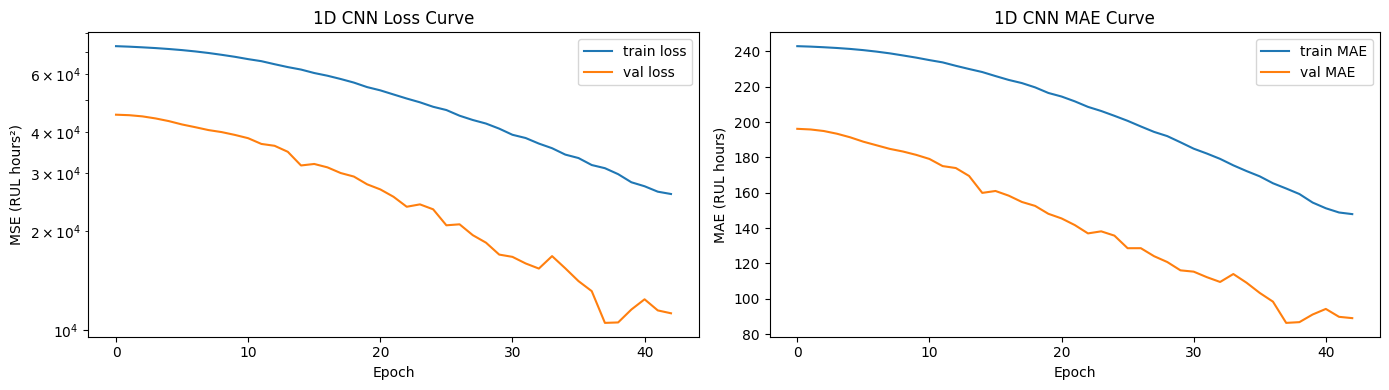


Final train loss: 25931.4336
Final val loss:   11236.7461
Overfit ratio (val/train): 0.43 (>1.5 = overfitting)
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Note: 'model' (Random Forest) not found - showing CNN only

MODEL COMPARISON ON TEST SET
            model  MAE_hours  RMSE_hours
1D CNN (sequence)   120.8444  143.651521


In [3]:
# ====================================================
# COMPLETE 1D CNN PIPELINE (includes data setup)
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ====================================================
# >>> LOAD YOUR DATA HERE (replace with your actual data loading) <<<
# ====================================================
# Example: If you have a CSV file, uncomment and modify:
# df = pd.read_csv("your_data.csv")
# train_df = df[df["split"] == "train"].copy()
# test_df = df[df["split"] == "test"].copy()

# OR if train_df/test_df already exist from earlier cells, 
# make sure to run those cells first.

# --- FOR TESTING ONLY: Create dummy data if train_df doesn't exist ---
if "train_df" not in locals() and "train_df" not in globals():
    print("WARNING: train_df not found. Creating dummy data for testing...")
    np.random.seed(42)
    
    def create_dummy_data(n_runs=50, readings_per_run=100, n_features=10):
        data = []
        for run_id in range(n_runs):
            base_rul = np.random.uniform(100, 500)
            degradation_rate = np.random.uniform(0.5, 2.0)
            for i in range(readings_per_run):
                rul = max(0, base_rul - degradation_rate * i)
                features = np.random.randn(n_features) * (1 + 0.01 * (base_rul - rul))
                data.append({
                    "run_id": f"run_{run_id:03d}",
                    "timestamp": pd.Timestamp("2024-01-01") + pd.Timedelta(hours=i),
                    "window_index": i,
                    "RUL_hours": rul,
                    **{f"feature_{j}": features[j] for j in range(n_features)}
                })
        return pd.DataFrame(data)
    
    dummy_df = create_dummy_data()
    train_df = dummy_df[dummy_df["run_id"].str.endswith(("0","1","2","3","4","5","6","7"))].copy()
    test_df = dummy_df[~dummy_df["run_id"].isin(train_df["run_id"])].copy()
    print(f"Created dummy: train={len(train_df)}, test={len(test_df)}")
else:
    print(f"Using existing data: train={len(train_df)}, test={len(test_df)}")

# ====================================================
# DEFINE FEATURE COLUMNS (update to match your actual features)
# ====================================================
if "SELECTED_FEATURE_COLS" not in locals() and "SELECTED_FEATURE_COLS" not in globals():
    feature_cols = [c for c in train_df.columns if c.startswith("feature_")]
    SELECTED_FEATURE_COLS = feature_cols
    print(f"Auto-detected features: {SELECTED_FEATURE_COLS}")
else:
    print(f"Using SELECTED_FEATURE_COLS: {SELECTED_FEATURE_COLS}")

if "MODEL_FEATURES" not in locals() and "MODEL_FEATURES" not in globals():
    MODEL_FEATURES = SELECTED_FEATURE_COLS

# ====================================================
# Build rolling sequences of consecutive readings (per run)
# ====================================================
SEQ_LEN = 20

def build_sequences(df, feature_cols, target_col, seq_len):
    X, y, meta = [], [], []
    for run_id, run_df in df.groupby("run_id"):
        run_df = run_df.sort_values(["timestamp", "window_index"]).reset_index(drop=True)
        feats = run_df[feature_cols].values
        targets = run_df[target_col].values
        for i in range(seq_len - 1, len(run_df)):
            X.append(feats[i - seq_len + 1: i + 1])
            y.append(targets[i])
            meta.append((run_id, run_df["timestamp"].iloc[i], run_df["window_index"].iloc[i]))
    return np.array(X), np.array(y), meta

# ====================================================
# Scale (fit on train only) then build sequences
# ====================================================
scaler_cnn = StandardScaler().fit(train_df[SELECTED_FEATURE_COLS])

train_scaled = train_df.copy()
train_scaled[SELECTED_FEATURE_COLS] = scaler_cnn.transform(train_df[SELECTED_FEATURE_COLS])

test_scaled = test_df.copy()
test_scaled[SELECTED_FEATURE_COLS] = scaler_cnn.transform(test_df[SELECTED_FEATURE_COLS])

X_train_seq, y_train_seq, train_seq_meta = build_sequences(
    train_scaled, SELECTED_FEATURE_COLS, "RUL_hours", SEQ_LEN
)
X_test_seq, y_test_seq, test_seq_meta = build_sequences(
    test_scaled, SELECTED_FEATURE_COLS, "RUL_hours", SEQ_LEN
)

print(f"\nTrain sequences: {X_train_seq.shape}")
print(f"Test sequences : {X_test_seq.shape}")

# ====================================================
# RUN-BASED VALIDATION SPLIT (prevents data leakage)
# ====================================================
unique_train_runs = train_df["run_id"].unique()
np.random.seed(42)
val_runs = np.random.choice(unique_train_runs, size=int(0.15 * len(unique_train_runs)), replace=False)
val_run_set = set(val_runs)

train_mask = np.array([m[0] not in val_run_set for m in train_seq_meta])
val_mask = np.array([m[0] in val_run_set for m in train_seq_meta])

X_train_final = X_train_seq[train_mask]
y_train_final = y_train_seq[train_mask]
X_val = X_train_seq[val_mask]
y_val = y_train_seq[val_mask]

print(f"Run-based split: Train={len(X_train_final)}, Val={len(X_val)}, Test={len(X_test_seq)}")

# ====================================================
# 1D CNN model with anti-overfitting measures
# ====================================================
n_features = len(SELECTED_FEATURE_COLS)

cnn_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features)),
    layers.Conv1D(16, kernel_size=3, activation="relu", padding="causal",
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Conv1D(32, kernel_size=3, activation="relu", padding="causal",
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, name="RUL_hours_pred")
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
cnn_model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
cnn_model.summary()

# ====================================================
# Train with enhanced callbacks
# ====================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, min_delta=1e-4
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = cnn_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (RUL hours²)")
axes[0].set_title("1D CNN Loss Curve")
axes[0].legend()
axes[0].set_yscale("log")

axes[1].plot(history.history["mae"], label="train MAE")
axes[1].plot(history.history["val_mae"], label="val MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (RUL hours)")
axes[1].set_title("1D CNN MAE Curve")
axes[1].legend()
plt.tight_layout()
plt.show()

# Overfitting check
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]
overfit_ratio = final_val_loss / final_train_loss if final_train_loss > 0 else float('inf')
print(f"\nFinal train loss: {final_train_loss:.4f}")
print(f"Final val loss:   {final_val_loss:.4f}")
print(f"Overfit ratio (val/train): {overfit_ratio:.2f} (>1.5 = overfitting)")

# ====================================================
# Evaluate and compare with RF
# ====================================================
cnn_pred = cnn_model.predict(X_test_seq).ravel()

eval_meta = pd.DataFrame(test_seq_meta, columns=["run_id", "timestamp", "window_index"])
eval_df = test_df.merge(eval_meta, on=["run_id", "timestamp", "window_index"], how="inner")
eval_df = eval_df.sort_values(["run_id", "timestamp", "window_index"]).reset_index(drop=True)

# CNN metrics
cnn_mae = mean_absolute_error(y_test_seq, cnn_pred)
cnn_rmse = np.sqrt(mean_squared_error(y_test_seq, cnn_pred))

# RF metrics (only if model exists)
if "model" in locals() or "model" in globals():
    rf_pred_aligned = model.predict(eval_df[MODEL_FEATURES])
    rf_mae = mean_absolute_error(eval_df["RUL_hours"], rf_pred_aligned)
    rf_rmse = np.sqrt(mean_squared_error(eval_df["RUL_hours"], rf_pred_aligned))
    
    comparison_df = pd.DataFrame({
        "model": ["1D CNN (sequence)", "Random Forest (single)"],
        "MAE_hours": [cnn_mae, rf_mae],
        "RMSE_hours": [cnn_rmse, rf_rmse]
    })
else:
    print("\nNote: 'model' (Random Forest) not found - showing CNN only")
    comparison_df = pd.DataFrame({
        "model": ["1D CNN (sequence)"],
        "MAE_hours": [cnn_mae],
        "RMSE_hours": [cnn_rmse]
    })

print("\n" + "="*60)
print("MODEL COMPARISON ON TEST SET")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

## Updated answer: is this a time-series ML workflow now?

**Yes, for the 1D CNN — no longer just "data that happens to be a time series."** It's given an ordered window of past readings and convolves across the time axis, so it can actually respond to *trends* (e.g. RMS rising over the last 20 readings), not just the instantaneous values in a single reading. Causal padding also means it never sees the future at inference time, which matches a real deployment.

The **Random Forest stays non-time-series on purpose** — it's the deliberate baseline so you can see, from `comparison_df` and the plot above, how much the sequence/time-awareness is actually buying you over a plain row-by-row model on this dataset.

One honesty note: the CNN comparison above is a **single held-out run**, not leave-one-run-out like the Random Forest in Step 9 — training 4 separate CNNs multiplies runtime ~4x, so I left that out for now. The code structure to extend it is identical (wrap Steps 10–11 in the same `LeaveOneGroupOut` loop from Step 9) if you want a more robust comparison across all 4 runs.